## Database

In [1]:
# Code to assess Postgres SQL came from previous class assignment
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def execute_query(query):
    try:
        # connect to a PostgresSQL database
        conn = psycopg2.connect(
        host="localhost",
        database="Capstone",   # sepcify dataabse to connect to
        user="postgres",        # deafult user name
        password="Boeing747!")      # password
        
        # create a cursor
        cur = conn.cursor()
        # execute query
        cur.execute(query)
        
        # fetch the result and store into a python dataframe
        rows=cur.fetchall()
        colnames = [desc[0] for desc in cur.description]
        return pd.DataFrame(rows, columns = colnames)
        
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
    finally:
        if conn is not None:
            conn.close()        # close the communication with the PostgreSQL

## Code in SQL

In [4]:
# Determine database is connected
query = """
SELECT COUNT(*) FROM accidents;
"""
result=execute_query(query)
print(result)

    count
0  224704


In [6]:
# Display first 5 rows from database
query = """
SELECT * FROM accidents;
"""
df = execute_query(query)
df.head(5)

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,CSX,CSX Transportation,2010,74979,https://safetydata.fra.dot.gov/Officeofsafety/...,10,4,None,None,None,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
1,BNSF,BNSF Railway Company,2010,KS1210112,https://safetydata.fra.dot.gov/Officeofsafety/...,10,12,None,None,None,...,BNSF Railway Company,BNSF Railway Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
2,RT,RIVER TERMINAL RWY CO.,1989,RT10589,https://safetydata.fra.dot.gov/Officeofsafety/...,89,10,None,None,None,...,RIVER TERMINAL RWY CO.,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,None
3,CO,CHESAPEAKE & OHIO RAILWAY CO.,1983,AOH0114,https://safetydata.fra.dot.gov/Officeofsafety/...,83,6,None,None,None,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,None
4,BN,Burlington Northern Railroad Company,1981,DK0062,https://safetydata.fra.dot.gov/Officeofsafety/...,81,1,None,None,None,...,BNSF Railway Company,BNSF Railway Company,Not Assigned,Not Assigned,Not Assigned,Not Assigned,Not Assigned,Not Assigned,Not Assigned,None


## Initial Data Review

In [7]:
# Data size
df.shape

(224704, 155)

In [8]:
# Brief information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224704 entries, 0 to 224703
Columns: 155 entries, Reporting Railroad Code to Location
dtypes: float64(25), int64(49), object(81)
memory usage: 265.7+ MB


In [9]:
# Numeric statistics
df.describe()

,Year,Accident Year,Accident Month,Other Accident Year,Other Accident Month,Maintenance Accident Year,Maintenance Accident Month,Day,Accident Type Code,Hazmat Cars,...,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Latitude,Longitude,Joint CD
count,224704.000000,224704.000000,224704.000000,19502.000000,19502.000000,224702.000000,224702.000000,224704.000000,224704.000000,224704.000000,...,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,70136.000000,70152.000000,224704.000000
mean,1993.240200,57.764641,6.432872,57.673110,6.440929,57.764942,6.432876,15.684420,3.406508,1.354395,...,0.032385,0.015078,0.158974,0.019417,0.210566,0.010378,0.126869,20.263719,-49.744623,1.311508
std,15.200545,35.285135,3.453805,35.158877,3.461773,35.285149,3.453787,8.753871,3.902550,6.391976,...,2.545053,0.206705,3.435767,0.259472,3.844788,0.183276,3.406570,19.174951,47.166292,0.678269
min,1975.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-181.078754,1.000000
25%,1979.000000,17.000000,3.000000,17.000000,3.000000,17.000000,3.000000,8.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-92.063158,1.000000
50%,1990.000000,77.000000,6.000000,77.000000,6.000000,77.000000,6.000000,16.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.915840,-75.082625,1.000000
75%,2005.000000,84.000000,9.000000,83.000000,9.000000,84.000000,9.000000,23.000000,4.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.128507,0.000000,1.000000
max,2026.000000,99.000000,12.000000,99.000000,12.000000,99.000000,12.000000,31.000000,13.000000,182.000000,...,999.000000,47.000000,558.000000,47.000000,558.000000,47.000000,1000.000000,64.845300,0.000000,3.000000


In [10]:
# Null values present - will be one of the more difficult tasks 
df.isna().sum()

Reporting Railroad Code                       0
Reporting Railroad Name                       3
Year                                          0
Accident Number                               0
PDF Link                                      4
                                          ...  
Reporting Railroad Switching Terminal         3
Reporting Railroad Tourist                    3
Reporting Railroad Freight                    3
Reporting Railroad Short Line                 3
Location                                 154568
Length: 155, dtype: int64

In [11]:
# For the time-being, missing values were filled with the mean
df = df.fillna(df.mean(numeric_only=True))

In [12]:
# Data type review
pd.set_option('display.max_rows',None)
df.dtypes

Reporting Railroad Code                   object
Reporting Railroad Name                   object
Year                                       int64
Accident Number                           object
PDF Link                                  object
Accident Year                              int64
Accident Month                             int64
Other Railroad Code                       object
Other Railroad Name                       object
Other Accident Number                     object
Other Accident Year                      float64
Other Accident Month                     float64
Maintenance Railroad Code                 object
Maintenance Railroad Name                 object
Maintenance Accident Number               object
Maintenance Accident Year                float64
Maintenance Accident Month               float64
Grade Crossing ID                         object
Day                                        int64
Date                                      object
Time                

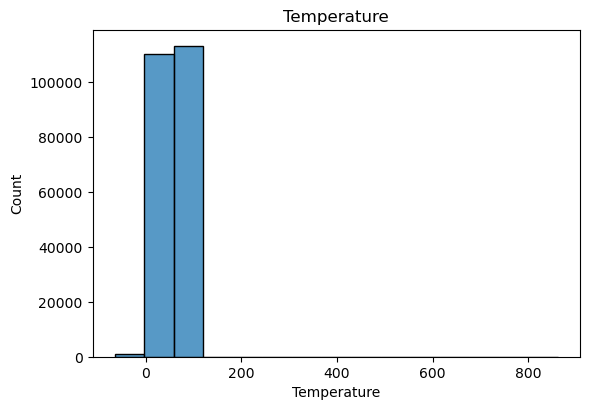

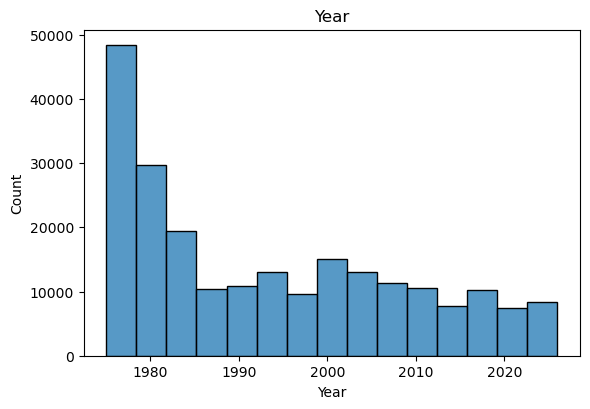

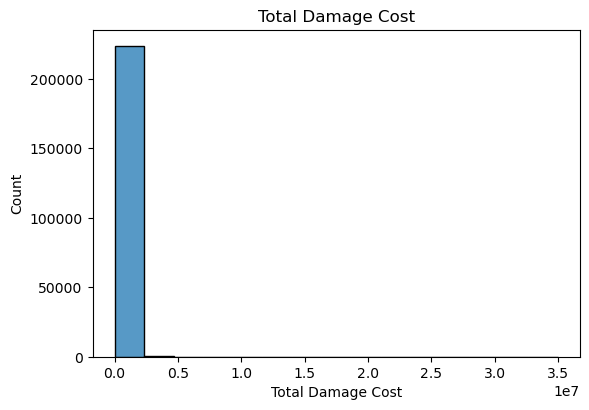

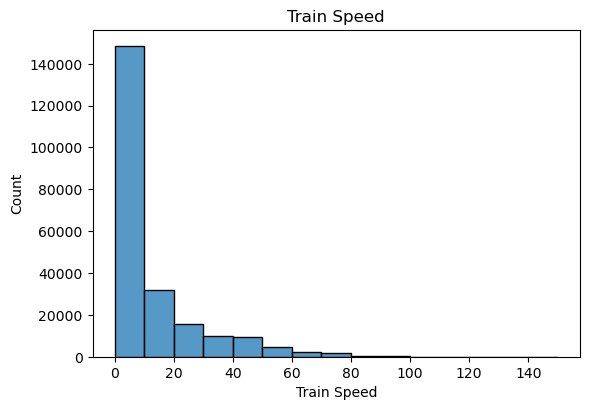

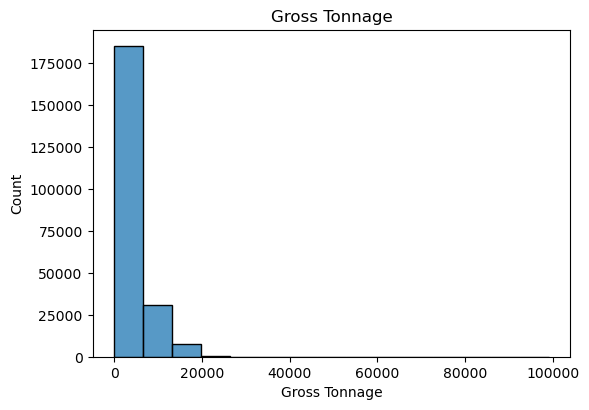

In [13]:
# Distribution Charts
# Claude AI was used to fix layout format so all histograms are legible - no solid solution. I decided to select specific features.
cols = ['Temperature','Year','Total Damage Cost','Train Speed','Gross Tonnage']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=15)
    plt.tight_layout()
    plt.title(col)
    plt.show()